In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_probability as tfp
import tensorflow as tf
import warnings

warnings.filterwarnings('ignore')

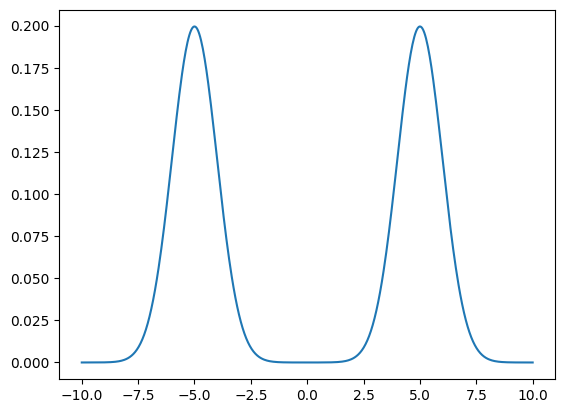

In [22]:
target_distribution = lambda x: (
    np.exp(-0.5*(x-5)**2) + np.exp(-0.5*(x+5)**2)
)/(np.sqrt(2*np.pi)*2)

x = np.linspace(-10, 10, 500)
plt.plot(x, target_distribution(x))
plt.show()

In [23]:
def log_prob(x):
    return tf.math.log(tf.exp(-0.5*(x-5)**2) + tf.exp(-0.5*(x+5)**2))


hmc = tfp.mcmc.HamiltonianMonteCarlo(
    target_log_prob_fn=log_prob,
    step_size=0.1,
    num_leapfrog_steps=3
)

samples, kernel_results = tfp.mcmc.sample_chain(
num_results=1000,
current_state=tf.constant(0.0),
kernel=hmc,
num_burnin_steps=500
)

samples = samples.numpy()

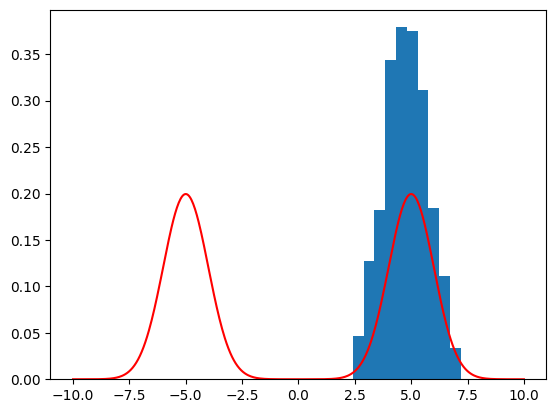

In [24]:
plt.hist(samples, density=True)
plt.plot(x, target_distribution(x), color="red")
plt.show()

In [26]:
def threaded_sampling(transition_kernel, threads, rng):
    starting_states = rng.normal(size=threads)
    thread_samples = []

    for starting_state in starting_states:
        thread, _ = tfp.mcmc.sample_chain(
            num_results=500,
            current_state=tf.constant(starting_state),
            kernel=transition_kernel,
            num_burnin_steps=250
        )
        thread_samples.extend(thread.numpy())

    return thread_samples, starting_states

rng = np.random.RandomState(1)
thread_samples, starting_states = threaded_sampling(hmc, 3, rng)

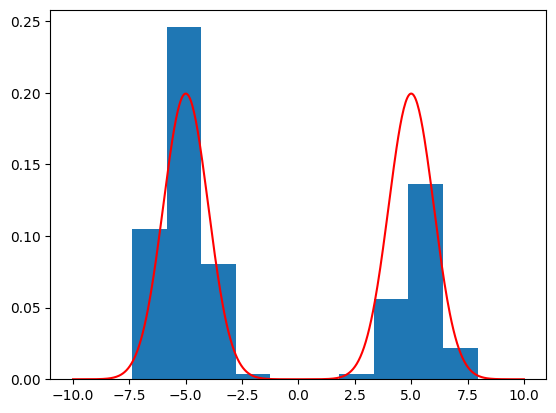

In [27]:
plt.hist(thread_samples, density=True)
plt.plot(x, target_distribution(x), color="red")
plt.show()

In [31]:
print(starting_states)

[ 1.62434536 -0.61175641 -0.52817175]
